# Mini Project: High-Performance Computing and Computer Vision

# Track C: JIT Compilation

Project submission is located here:
* [Project submission](../project/project.md)

# Setup

## Environment setup

Install required libraries for object detection (Ultralytics YOLO), dataset loading (Hugging Face), image handling (OpenCV+pillow), and JIT compilation (Numba).

In [24]:
!pip install ultralytics datasets opencv-python pillow numba

## Test Setup

### Get Image dataset
160 images of traffic from Hugging Face dataset

In [25]:
#from huggingface_hub import login
#login("YYY")

In [26]:
import os
from pathlib import Path

image_dir = Path("traffic_images")
image_dir.mkdir(exist_ok=True)

# Check if images already exist
existing_images = list(image_dir.glob("*.jpg"))

if len(existing_images) > 0:
    print(f"Found {len(existing_images)} existing images. Skipping download.")
    image_paths = [str(p) for p in existing_images]

else:
    print("No saved images found. Downloading dataset and saving images...")

    from datasets import load_dataset
    dataset = load_dataset("AITC-Traffic-Density/Traffic-Object-Detection")

    image_paths = []

    for split_name in dataset.keys():
        for i, item in enumerate(dataset[split_name]):
            img = item["image"]
            path = image_dir / f"{split_name}_img_{i}.jpg"
            img.save(path)
            image_paths.append(str(path))

    print(f"Saved {len(image_paths)} images to {image_dir}")

print("First 5 paths:", image_paths[:5])

Found 160 existing images. Skipping download.
First 5 paths: ['traffic_images/train_img_31.jpg', 'traffic_images/validation_img_20.jpg', 'traffic_images/train_img_17.jpg', 'traffic_images/train_img_53.jpg', 'traffic_images/test_img_1.jpg']


## Run inference

In [27]:
import random
import numpy as np
from ultralytics import YOLO

# --- Load model ---
model = YOLO("yolov8n.pt")  # adjust if needed

# --- Collect all image paths ---
#image_paths = [str(p) for p in image_dir.glob("*.jpg")]

# --- Sample 1 random images ---
# sample_paths = random.sample(image_paths, min(1, len(image_paths)))
sample_paths = image_paths # do all

# --- Storage for later use ---
all_boxes = []
all_scores = []
all_classes = []

# --- Stats tracking ---
num_boxes_list = []

print("Running inference on images...\n")

for i, path in enumerate(sample_paths, 1):
    result = model.predict(path, conf=0.1, verbose=False)[0]

    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy()

    num_boxes = len(boxes)
    num_cars = np.sum(classes == 2)     # class 2 = car
    num_persons = np.sum(classes == 0)  # class 0 = person
    avg_conf = float(scores.mean()) if num_boxes > 0 else 0.0

    num_boxes_list.append(num_boxes)

    all_boxes.append(boxes)
    all_scores.append(scores)
    all_classes.append(classes)

    print(f"Image {i}:")
    print(f"  total boxes: {num_boxes}")
    print(f"  cars: {num_cars}")
    print(f"  persons: {num_persons}")
    print(f"  avg confidence: {avg_conf:.3f}\n")

# --- Summary ---
if num_boxes_list:
    print("Summary:")
    print(f"  avg boxes/image: {np.mean(num_boxes_list):.2f}")
    print(f"  max boxes/image: {np.max(num_boxes_list)}")
    print(f"  min boxes/image: {np.min(num_boxes_list)}")
else:
    print("No detections found.")

# --- Flatten all boxes for future IoU / JIT experiments ---
if all_boxes:
    flat_boxes = np.vstack([b for b in all_boxes if len(b) > 0]) if any(len(b) > 0 for b in all_boxes) else np.empty((0, 4))
    print(f"\nTotal boxes across all images: {len(flat_boxes)}")

Running inference on images...

Image 1:
  total boxes: 7
  cars: 3
  persons: 0
  avg confidence: 0.182

Image 2:
  total boxes: 36
  cars: 20
  persons: 8
  avg confidence: 0.229

Image 3:
  total boxes: 13
  cars: 7
  persons: 1
  avg confidence: 0.305

Image 4:
  total boxes: 3
  cars: 0
  persons: 0
  avg confidence: 0.127

Image 5:
  total boxes: 16
  cars: 11
  persons: 0
  avg confidence: 0.348

Image 6:
  total boxes: 1
  cars: 0
  persons: 0
  avg confidence: 0.163

Image 7:
  total boxes: 3
  cars: 1
  persons: 0
  avg confidence: 0.239

Image 8:
  total boxes: 9
  cars: 5
  persons: 0
  avg confidence: 0.377

Image 9:
  total boxes: 2
  cars: 0
  persons: 0
  avg confidence: 0.157

Image 10:
  total boxes: 10
  cars: 1
  persons: 2
  avg confidence: 0.289

Image 11:
  total boxes: 6
  cars: 1
  persons: 0
  avg confidence: 0.268

Image 12:
  total boxes: 13
  cars: 7
  persons: 3
  avg confidence: 0.294

Image 13:
  total boxes: 5
  cars: 0
  persons: 0
  avg confidence: 0.

# IoU calculations

## Baseline Python IoU calculation

In [28]:
# baseline Python IoU + benchmark
import time
import numpy as np

def compute_iou_python(box_a, box_b):
    # box: numpy [x_min, y_min, x_max, y_max]
    # Image coordinate system; origin (0,0) is top-left. X increases to the right. Y increases downwards
    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    inter_w = max(0.0, x_right - x_left)
    inter_h = max(0.0, y_bottom - y_top)
    intersection = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])

    union = area_a + area_b - intersection

    if union <= 0.0:
        return 0.0

    return intersection / union


def iou_matrix_python(boxes):
    n = boxes.shape[0]
    out = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(n):
            out[i, j] = compute_iou_python(boxes[i], boxes[j])

    return out



## Numba JIT IoU implications

In [29]:
import time
import numpy as np
from numba import njit

# ----------------------------
# Numba IoU implementation
# ----------------------------
@njit
def compute_iou_numba(box_a, box_b):
    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    inter_w = max(0.0, x_right - x_left)
    inter_h = max(0.0, y_bottom - y_top)
    intersection = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])

    union = area_a + area_b - intersection
    if union <= 0.0:
        return 0.0

    return intersection / union


@njit
def iou_matrix_numba(boxes):
    n = boxes.shape[0]
    out = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(n):
            out[i, j] = compute_iou_numba(boxes[i], boxes[j])

    return out

# Benchmark: First-run comparison: Python execution vs Numba compile + execution

In [30]:
import time
import numpy as np

def get_numba_first_call_time(all_boxes):
    if "numba_first_call_time" in globals():
        return numba_first_call_time

    for boxes in all_boxes:
        if len(boxes) > 0:
            boxes_f32 = boxes.astype(np.float32)
            start = time.perf_counter()
            _ = iou_matrix_numba(boxes_f32)
            return time.perf_counter() - start

numba_first_call_time = get_numba_first_call_time(all_boxes)
print(f"Stored Numba first-call time: {numba_first_call_time:.6f} s")

Stored Numba first-call time: 1.736264 s


In [31]:
import time
import numpy as np

if "python_first_call_time" not in globals():
    for boxes in all_boxes:
        if len(boxes) > 0:
            boxes_f32 = boxes.astype(np.float32)

            start = time.perf_counter()
            _ = iou_matrix_python(boxes_f32)
            python_first_call_time = time.perf_counter() - start
            break

print(f"Stored Python first-call time: {python_first_call_time:.6f} s")

Stored Python first-call time: 0.000748 s


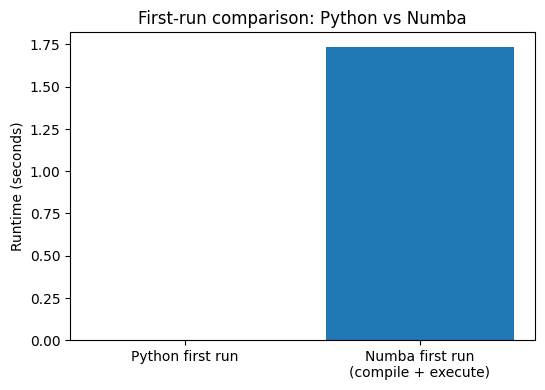

In [32]:
import matplotlib.pyplot as plt

labels = ["Python first run", "Numba first run\n(compile + execute)"]
times = [python_first_call_time, numba_first_call_time]

plt.figure(figsize=(6, 4))
plt.bar(labels, times)
plt.ylabel("Runtime (seconds)")
plt.title("First-run comparison: Python vs Numba")
plt.show()

# Benchmark: Python baseline vs Numba JIT implementation

This section compares the execution time of the IoU computation implemented in pure Python and using Numba JIT compilation.

50 repeats x 160 images

In [33]:

# ----------------------------
# Repeated benchmark functions
# ----------------------------
def benchmark_python_iou_repeated(all_boxes, repeats):
    start = time.perf_counter()
    final_outputs = []

    for r in range(repeats):
        run_outputs = []
        for boxes in all_boxes:
            if len(boxes) == 0:
                run_outputs.append(np.empty((0, 0), dtype=np.float32))
            else:
                run_outputs.append(iou_matrix_python(boxes.astype(np.float32)))
        if r == repeats - 1:
            final_outputs = run_outputs

    elapsed = time.perf_counter() - start
    return final_outputs, elapsed


def benchmark_numba_iou_repeated(all_boxes, repeats):
    # Warm-up compile
    for boxes in all_boxes:
        if len(boxes) > 0:
            _ = iou_matrix_numba(boxes.astype(np.float32))
            break

    start = time.perf_counter()
    final_outputs = []

    for r in range(repeats):
        run_outputs = []
        for boxes in all_boxes:
            if len(boxes) == 0:
                run_outputs.append(np.empty((0, 0), dtype=np.float32))
            else:
                run_outputs.append(iou_matrix_numba(boxes.astype(np.float32)))
        if r == repeats - 1:
            final_outputs = run_outputs

    elapsed = time.perf_counter() - start
    return final_outputs, elapsed


# ----------------------------
# Run repeated benchmark
# ----------------------------
repeats = 50

python_outputs, python_elapsed = benchmark_python_iou_repeated(all_boxes, repeats)
numba_outputs, numba_elapsed = benchmark_numba_iou_repeated(all_boxes, repeats)

print(f"Python repeated IoU time: {python_elapsed:.4f} s")
print(f"Numba repeated IoU time:  {numba_elapsed:.4f} s")
print(f"Speedup: {python_elapsed / numba_elapsed:.2f}x")


# ----------------------------
# Correctness check
# ----------------------------
all_match = True
max_abs_diff = 0.0

for py_mat, nb_mat in zip(python_outputs, numba_outputs):
    if py_mat.shape != nb_mat.shape:
        all_match = False
        print("Shape mismatch found.")
        break

    if py_mat.size > 0:
        diff = np.max(np.abs(py_mat - nb_mat))
        max_abs_diff = max(max_abs_diff, float(diff))
        mean_diff = np.mean(np.abs(py_mat - nb_mat))
        if not np.allclose(py_mat, nb_mat, atol=1e-6):
            all_match = False
            break

print("\nCorrectness check:")
print(f"  outputs match: {all_match}")
print(f"  max abs diff:  {max_abs_diff:.8f}")
print(f"  mean abs diff:  {mean_diff:.8f}")

Python repeated IoU time: 22.9804 s
Numba repeated IoU time:  0.0631 s
Speedup: 364.18x

Correctness check:
  outputs match: True
  max abs diff:  0.00000024
  mean abs diff:  0.00000000


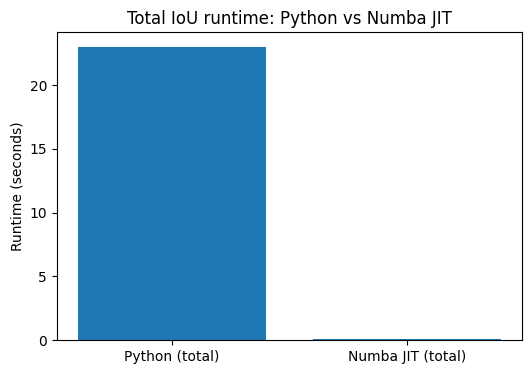

In [34]:
import matplotlib.pyplot as plt

labels = ["Python (total)", "Numba JIT (total)"]
times = [python_elapsed, numba_elapsed]

plt.figure(figsize=(6, 4))
plt.bar(labels, times)
plt.ylabel("Runtime (seconds)")
plt.title("Total IoU runtime: Python vs Numba JIT")
plt.show()

python runtime (ms) per image: 2.9845
Numba runtime (ms) per image: 0.0082


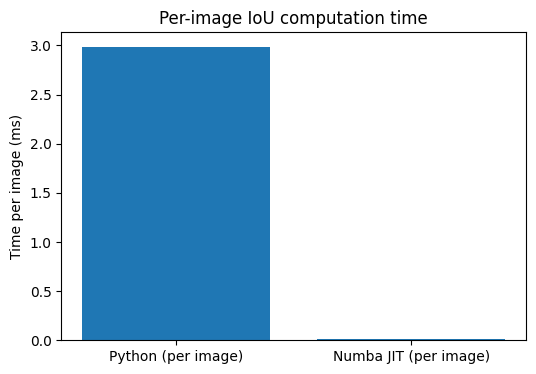

In [35]:
import matplotlib.pyplot as plt

num_images = sum(1 for b in all_boxes if len(b) > 0)

python_per_image = python_elapsed / (repeats * num_images)
numba_per_image = numba_elapsed / (repeats * num_images)

# Convert to milliseconds
python_ms = python_per_image * 1000
numba_ms = numba_per_image * 1000

print(f"python runtime (ms) per image: {python_ms:.4f}")
print(f"Numba runtime (ms) per image: {numba_ms:.4f}")

labels = ["Python (per image)", "Numba JIT (per image)"]
times = [python_ms, numba_ms]

plt.figure(figsize=(6, 4))
plt.bar(labels, times)
plt.ylabel("Time per image (ms)")
plt.title("Per-image IoU computation time")
plt.show()

# Appendix

## Hardware info

In [36]:
from psutil import *
# This code will return the number of CPU
print("Number of CPU: ", cpu_count())
print("virtual memory: ", virtual_memory())
# This code will return the CPU info
!cat /proc/cpuinfo

Number of CPU:  2
virtual memory:  svmem(total=13605834752, available=11440680960, percent=15.9, used=1826320384, free=9182150656, active=802390016, inactive=3246874624, buffers=176025600, cached=2421338112, shared=5365760, slab=268165120)
processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 79
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2199.998
cache size	: 56320 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm rd